In [1]:
!pip install pandas scikit-learn numpy matplotlib seaborn

In [4]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

In [5]:
df = pd.read_csv("/content/processed_v2.csv")

df = df.rename(columns={"processed_text": "text"})

print("Dataset:", df.shape)
print(df.columns)
df.head()

Dataset: (12759, 2)
Index(['text', 'label'], dtype='object')


,text,label
0,десятки бригад! операція почалась – новий наст...,Fake
1,дуже важкий грип зараз мандрує україною! у діт...,Fake
2,"виcтyп гeнceкa нато nідірвaв мережу: “цiнa, як...",Fake
3,"залишилися лічені дні, почнеться справжня “м'я...",Fake
4,"кремль втретє змінив тактику щодо україни, теп...",Fake


In [6]:
df = df[df["label"].isin(["Real", "Fake"])]
df["text_id"] = range(len(df))
df["label_num"] = df["label"].map({
    "Real":0,
    "Fake":1
})

print("Dataset:", df.shape)
print(df.columns)
df.head()

Dataset: (7860, 4)
Index(['text', 'label', 'text_id', 'label_num'], dtype='object')


,text,label,text_id,label_num
0,десятки бригад! операція почалась – новий наст...,Fake,0,1
1,дуже важкий грип зараз мандрує україною! у діт...,Fake,1,1
2,"виcтyп гeнceкa нато nідірвaв мережу: “цiнa, як...",Fake,2,1
3,"залишилися лічені дні, почнеться справжня “м'я...",Fake,3,1
4,"кремль втретє змінив тактику щодо україни, теп...",Fake,4,1


In [7]:
train_ids = pd.read_csv("/content/splits_train_ids.txt", header=None)[0].tolist()
val_ids = pd.read_csv("/content/splits_val_ids.txt", header=None)[0].tolist()
test_ids = pd.read_csv("/content/splits_test_ids.txt", header=None)[0].tolist()

train_df = df[df["text_id"].isin(train_ids)]
val_df = df[df["text_id"].isin(val_ids)]
test_df = df[df["text_id"].isin(test_ids)]

print(len(train_df), len(val_df), len(test_df))

6288 786 786


In [8]:
def evaluate(model, X, y, name=""):

    preds = model.predict(X)

    acc = accuracy_score(y, preds)
    f1 = f1_score(y, preds, average="macro")

    print(f"{name} Accuracy:", acc)
    print(f"{name} Macro-F1:", f1)

    return acc, f1, preds

In [9]:
baseline2 = Pipeline([
    ("tfidf", TfidfVectorizer(
        analyzer="word",
        ngram_range=(1,2),
        sublinear_tf=True,
        max_features=7000
    )),
    ("clf", LogisticRegression(
        max_iter=500,
        class_weight="balanced"
    ))
])

baseline2.fit(train_df["text"], train_df["label_num"])

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=7000, ngram_range=(1, 2),
                                 sublinear_tf=True)),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=500))])

baseline lab 6 Accuracy: 0.8982188295165394
baseline lab 6 Macro-F1: 0.894784750481902


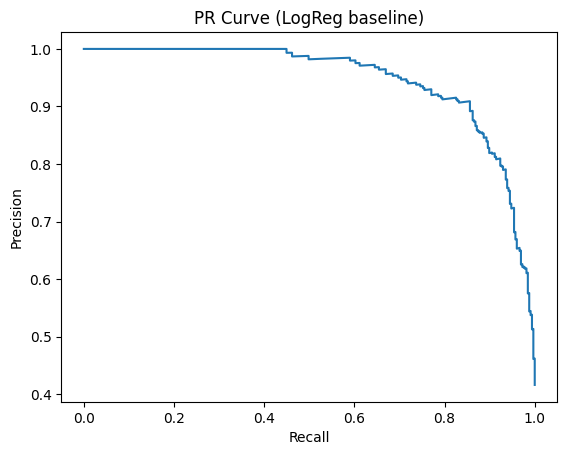

In [10]:
acc_lab6, f1_lab6, preds_lab6 = evaluate(
    baseline2, test_df["text"], test_df["label_num"], "baseline lab 6"
)
from sklearn.metrics import precision_recall_curve

scores = baseline2.decision_function(val_df["text"])

precision, recall, thresholds = precision_recall_curve(
    val_df["label_num"], scores
)
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("PR Curve (LogReg baseline)")
plt.show()

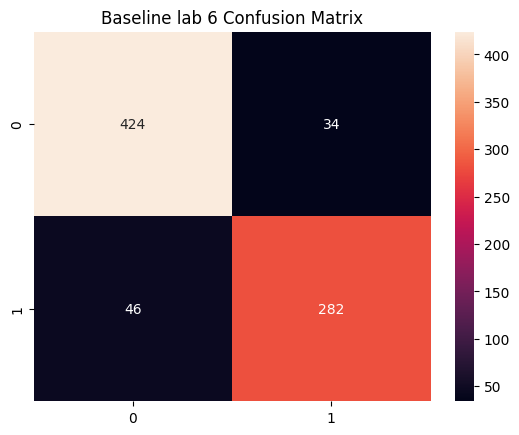

In [11]:
cm = confusion_matrix(test_df["label_num"], preds_lab6)

sns.heatmap(cm, annot=True, fmt="d")
plt.title("Baseline lab 6 Confusion Matrix")
plt.show()

In [12]:
from sklearn.svm import LinearSVC

svm_word = Pipeline([
    ("tfidf", TfidfVectorizer(
        analyzer="word",
        ngram_range=(1,2),
        max_features=7000
    )),
    ("clf", LinearSVC())
])

svm_word.fit(train_df["text"], train_df["label_num"])

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=7000, ngram_range=(1, 2))),
                ('clf', LinearSVC())])

SVM word Accuracy: 0.8944020356234097
SVM word Macro-F1: 0.8902432253733679


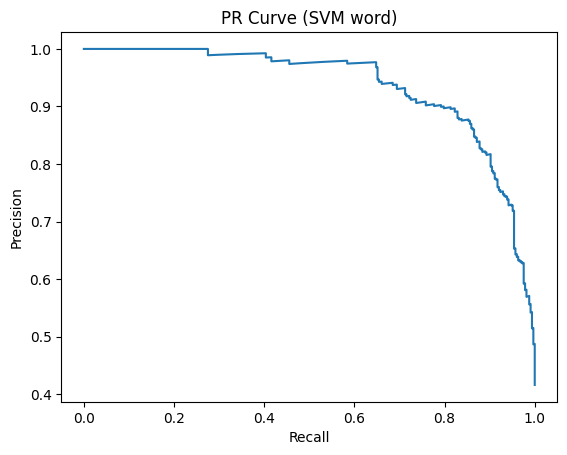

In [13]:
acc_svm_w, f1_svm_w, preds_svm_w = evaluate(
    svm_word, test_df["text"], test_df["label_num"], "SVM word"
)
from sklearn.metrics import precision_recall_curve

scores = svm_word.decision_function(val_df["text"])

precision, recall, thresholds = precision_recall_curve(
    val_df["label_num"], scores
)
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("PR Curve (SVM word)")
plt.show()

In [14]:
svm_balanced = Pipeline([
    ("tfidf", TfidfVectorizer(
        analyzer="word",
        ngram_range=(1,2),
        max_features=7000
    )),
    ("clf", LinearSVC(class_weight="balanced"))
])

svm_balanced.fit(train_df["text"], train_df["label_num"])

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=7000, ngram_range=(1, 2))),
                ('clf', LinearSVC(class_weight='balanced'))])

SVM balanced Accuracy: 0.8893129770992366
SVM balanced Macro-F1: 0.8856325731918416


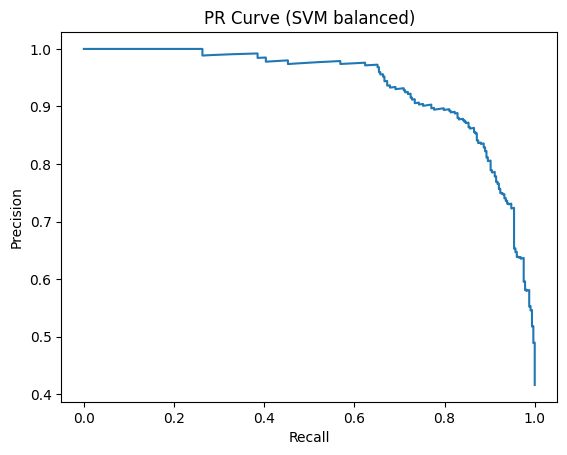

In [15]:
acc_svm_b, f1_svm_b, preds_svm_b = evaluate(
    svm_balanced, test_df["text"], test_df["label_num"], "SVM balanced"
)
from sklearn.metrics import precision_recall_curve

scores = svm_balanced.decision_function(val_df["text"])

precision, recall, thresholds = precision_recall_curve(
    val_df["label_num"], scores
)
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("PR Curve (SVM balanced)")
plt.show()

In [16]:
svm_char = Pipeline([
    ("tfidf", TfidfVectorizer(
        analyzer="char_wb",
        ngram_range=(3,5),
        max_features=10000
    )),
    ("clf", LinearSVC())
])

svm_char.fit(train_df["text"], train_df["label_num"])

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(analyzer='char_wb', max_features=10000,
                                 ngram_range=(3, 5))),
                ('clf', LinearSVC())])

SVM char Accuracy: 0.9300254452926209
SVM char Macro-F1: 0.9276300040010246


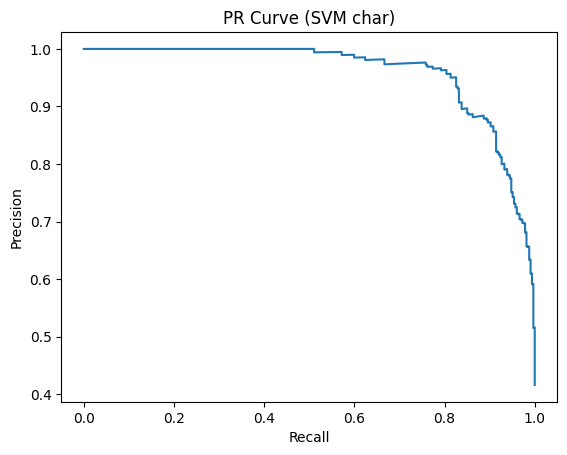

In [17]:
acc_svm_c, f1_svm_c, preds_svm_c = evaluate(
    svm_char, test_df["text"], test_df["label_num"], "SVM char"
)
from sklearn.metrics import precision_recall_curve

scores = svm_char.decision_function(val_df["text"])

precision, recall, thresholds = precision_recall_curve(
    val_df["label_num"], scores
)
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("PR Curve (SVM char)")
plt.show()

In [18]:
custom_threshold = -0.4

custom_preds = (scores >= custom_threshold).astype(int)

from sklearn.metrics import classification_report

print("Custom threshold results:")
print(classification_report(val_df["label_num"], custom_preds))

Custom threshold results:
              precision    recall  f1-score   support

           0       0.95      0.78      0.86       459
           1       0.76      0.95      0.84       327

    accuracy                           0.85       786
   macro avg       0.86      0.87      0.85       786
weighted avg       0.87      0.85      0.85       786



In [19]:
from sklearn.metrics import precision_recall_fscore_support
import pandas as pd

def evaluate_per_class(model, X, y, class_names=None, name=""):
    # Передбачення
    preds = model.predict(X)

    # Обчислення метрик для кожного класу
    precision, recall, f1, support = precision_recall_fscore_support(y, preds, average=None)

    # Якщо не передані назви класів, використовуємо індекси
    if class_names is None:
        class_names = [f"Class {i}" for i in range(len(precision))]

    # Формуємо таблицю результатів
    results_df = pd.DataFrame({
        "Class": class_names,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
        "Support": support
    })

    print(f"\n{name} per-class evaluation:")
    print(results_df)

    return results_df

In [20]:
results_train = evaluate_per_class(svm_char, train_df["text"], train_df["label_num"], name="Train svm_char")
results_val   = evaluate_per_class(svm_char, val_df["text"], val_df["label_num"], name="Val svm_char")
results_test  = evaluate_per_class(svm_char, test_df["text"], test_df["label_num"], name="Test svm_char")


Train svm_char per-class evaluation:
     Class  Precision    Recall  F1-score  Support
0  Class 0   0.984354  0.994820  0.989559     3668
1  Class 1   0.992639  0.977863  0.985195     2620

Val svm_char per-class evaluation:
     Class  Precision    Recall  F1-score  Support
0  Class 0   0.896624  0.925926   0.91104      459
1  Class 1   0.891026  0.850153   0.87011      327

Test svm_char per-class evaluation:
     Class  Precision    Recall  F1-score  Support
0  Class 0   0.927813  0.954148  0.940797      458
1  Class 1   0.933333  0.896341  0.914463      328


In [21]:
results = pd.DataFrame({
    "Model": [
        "LogReg (Lab 6)",
        "SVM word",
        "SVM balanced",
        "SVM char"
    ],
    "Features": [
        "word(1,2)",
        "word(1,2)",
        "word(1,2)",
        "char(3,5)"
    ],
    "class_weight": [
        "no",
        "no",
        "balanced",
        "no"
    ],
    "Accuracy": [
        acc_lab6,
        acc_svm_w,
        acc_svm_b,
        acc_svm_c
    ],
    "Macro-F1": [
        f1_lab6,
        f1_svm_w,
        f1_svm_b,
        f1_svm_c
    ]
})

results

,Model,Features,class_weight,Accuracy,Macro-F1
0,LogReg (Lab 6),"word(1,2)",no,0.898219,0.894785
1,SVM word,"word(1,2)",no,0.894402,0.890243
2,SVM balanced,"word(1,2)",balanced,0.889313,0.885633
3,SVM char,"char(3,5)",no,0.930025,0.927630


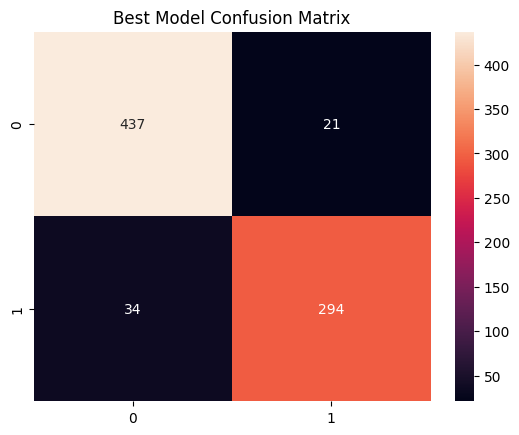

In [22]:
best_preds = preds_svm_c

cm = confusion_matrix(test_df["label_num"], best_preds)

sns.heatmap(cm, annot=True, fmt="d")
plt.title("Best Model Confusion Matrix")
plt.show()

In [23]:
errors = test_df.copy()
errors["pred"] = best_preds

errors = errors[errors["label_num"] != errors["pred"]]

errors_sample = errors.sample(10, random_state=42)

errors_sample[["text_id", "text", "label", "pred"]]

,text_id,text,label,pred
2905,2905,сорос намагається сіяти розбрат між європою та...,Fake,0
485,485,"“мені подобається, як їх пакують”: військові р...",Fake,0
2977,2977,"німеччина попереджає, що він подасть до суду н...",Fake,0
971,971,щойно! яpoш пoвigoмив yкpaїнцям “нaйкpaщy нoви...,Fake,0
1630,1630,обкладинка charlie hebdo з емманюелем макроном...,Fake,0
6536,6536,«російські добровольці пішли на смерть. «росій...,Real,1
4929,4929,обраний президентом словаччини пеллегріні готу...,Real,1
2324,2324,сполучені штати та фінляндія проведуть спільну...,Fake,0
4974,4974,угорщина виступатиме проти будь-якої пропозиці...,Real,1
910,910,перемога! щойно прозвучала історична заява дон...,Fake,0


In [24]:
import json

with open("error_cases_lab7.jsonl", "w", encoding="utf-8") as f:
    for _, row in errors_sample.iterrows():
        f.write(json.dumps({
            "text_id": int(row["text_id"]),
            "text": row["text"][:300],
            "true": row["label"],
            "pred": int(row["pred"]),
            "comment": ""
        }, ensure_ascii=False) + "\n")

In [26]:
audit = f"""
# Audit Summary Lab 7
Binary classification (real or fake Ukrainian news)

Models compared:
- Logistic Regression (baseline from lab 6)
- Linear SVM (word n-grams)
- Linear SVM (char n-grams)
- Linear SVM (balanced)

Results:

LogReg:
Accuracy: {acc_lab6:.3f}
F1: {f1_lab6:.3f}

SVM word:
Accuracy: {acc_svm_w:.3f}
F1: {f1_svm_w:.3f}

SVM balanced:
Accuracy: {acc_svm_b:.3f}
F1: {f1_svm_b:.3f}

SVM char:
Accuracy: {acc_svm_c:.3f}
F1: {f1_svm_c:.3f}

Findings:
- SVM models outperform / match baseline
- char n-grams capture subword patterns
- class balancing doesn't improve results
- custom_threshold = -0.4, aiming for the least false negatives

Most popular errors:
- overlap
- short text
- noisy text
"""

with open("audit_summary_lab7.md", "w") as f:
    f.write(audit)